In [24]:
# ----- A3: Berechnung des Trägheitsmoments in z-Richtung -----


# Set-Up
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

# ----- Teil 1: Mittlere Eigenfrequenzen berechnen -----

# --- Messwerte ---
freq = np.array([300,240])        #[1/min]
delta_freq = 5

# --- Berechnung ---
mittelwert = np.mean(freq)
standardabweichung = np.std(freq)

# --- Gesamtfehler ---
gesamter_fehler = np.sqrt(((standardabweichung)**2)/2 + ((delta_freq)**2)/4)

# ----- Ausgabe -----
print("Mittelwert =", mittelwert)
print("Gesamtfehler =", gesamter_fehler)

Mittelwert = 270.0
Gesamtfehler = 21.360009363293827



1 Gewicht bei 15 cm
Steigung s = 1.8958 ± 0.0488 s^2

1 Gewicht bei 20 cm
Steigung s = 1.4152 ± 0.0411 s^2

2 Gewichte bei 15 cm
Steigung s = 1.0148 ± 0.0350 s^2

2 Gewichte bei 20 cm
Steigung s = 0.7661 ± 0.0300 s^2


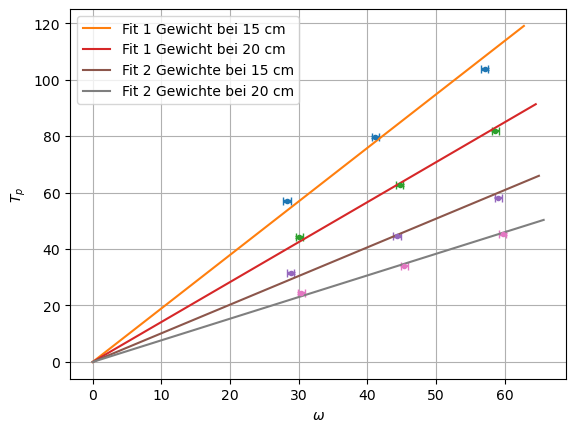

In [125]:
# ----- Teil 2: Präzessionszeit als Funktion der mittleren Eigenfrequenz -----

# Dämpfungskonstante
lambda_val = 0.0469 
error_lambda = 0.0010 

# ----- Messdaten -----
datasets = {
    "1 Gewicht bei 15 cm": {
        "omega_0": np.array([270, 393, 545]) * 2 * np.pi / 60,   # min^-1
        "err_omega": np.array([5, 5, 5]) * 2 * np.pi / 60,       # min^-1
        "T_p": np.array([56.92, 79.69, 103.64]),# s
        "err_T_p": np.array([0.3, 0.3, 0.3])    # s
    },

    "1 Gewicht bei 20 cm": {
        "omega_0": np.array([287, 427, 560]) * 2 * np.pi / 60,
        "err_omega": np.array([5, 5, 5]) * 2 * np.pi / 60,
        "T_p": np.array([44.22, 62.71, 81.96]),
        "err_T_p": np.array([0.3, 0.3, 0.3])
    },

    "2 Gewichte bei 15 cm": {
        "omega_0": np.array([275, 423, 564]) * 2 * np.pi / 60,
        "err_omega": np.array([5, 5, 5]) * 2 * np.pi / 60,
        "T_p": np.array([31.56, 44.57, 58.21]),
        "err_T_p": np.array([0.3, 0.3, 0.3])
    },

    "2 Gewichte bei 20 cm": {
        "omega_0": np.array([290, 433, 570]) * 2 * np.pi / 60,
        "err_omega": np.array([5, 5, 5]) * 2 * np.pi / 60,
        "T_p": np.array([24.34, 34.13, 45.33]),
        "err_T_p": np.array([0.3, 0.3, 0.3])
    }
}


plt.figure()

for label, data in datasets.items():

    # ----- Einlesen -----
    omega_0 = data["omega_0"]
    err_omega = data["err_omega"]
    T_p = data["T_p"]
    err_T_p = data["err_T_p"]
    
    # ----- Mittelwert -----
    omega_mean = (omega_0) / 1
    err_omega_mean = np.sqrt((err_omega)**2)

    # ----- Linearer Fit durch Ursprung -----
    w = 2 * np.pi /(T_p)
    slope = np.sum(w * omega_mean * T_p) / np.sum(w * omega_mean**2)
    error_slope = np.sqrt(1 / np.sum(w * omega_mean**2))

    # ----- Fitlinie -----
    omega_fit = np.linspace(0, max(omega_mean)*1.1, 100)
    T_p_fit = slope * omega_fit

    # ----- Plot -----
    plt.errorbar(
        omega_mean,
        T_p,
        xerr=err_omega_mean,
        yerr=err_T_p,
        fmt=".",
        capsize=3,
    )

    plt.plot(
        omega_fit,
        T_p_fit,
        "-",
        label=f"Fit {label}"
    )

    # ----- Ausgabe -----
    print(f"\n{label}")
    print(f"Steigung s = {slope:.4f} ± {error_slope:.4f} s^2")

# ----- Plotformat (außerhalb der Schleife) -----
plt.xlabel(r"$\omega$")
plt.ylabel(r"$T_p$")
plt.grid(True)
plt.legend()

plt.savefig("figures/Praezessionszeit in Abhängigkeit der Eigenfrequenz.png")
plt.show()

In [126]:
# ----- Teil 3: Berechnung des Trägheitsmoments -----

# ----- Messung 1 -----
m = 0.00985   * 1000    # Masse [kg]
g = 9.81      # Erdbeschleunigung [m/s²]
l = 0.2       # Länge [m]
dl = 0.001     # Fehler Länge [m]
da = 0.0411      # Fehler Steigung
a = 1.4152 

# --- Berechnung von I_z ---
I_z = m * g * l * a / (2 * np.pi)

# --- Fehler ΔI_z ---
delta_I_z = np.sqrt( ((m * g * a / (2*np.pi) * dl)**2) + ((m * g * l / (2*np.pi) * da)**2) )

# --- Ausgabe ---
print(f"Messung 1: I_z = {I_z:.4f} ± {delta_I_z:.4f}")





# ----- Messung 2 -----
m = 0.0197   * 1000    # Masse [kg]
g = 9.81      # Erdbeschleunigung [m/s²]
l = 0.2       # Länge [m]
dl = 0.001     # Fehler Länge [m]
da = 0.0300      # Fehler Steigung
a = 0.7661 

# --- Berechnung von I_z ---
I_z = m * g * l * a / (2 * np.pi)

# --- Fehler ΔI_z ---
delta_I_z = np.sqrt( ((m * g * a / (2*np.pi) * dl)**2) + ((m * g * l / (2*np.pi) * da)**2) )

# --- Ausgabe ---
print(f"Messung 2: I_z = {I_z:.4f} ± {delta_I_z:.4f}")



# ----- Messung 3 -----
m = 0.00985 * 1000      # Masse [kg]
g = 9.81      # Erdbeschleunigung [m/s²]
l = 0.15       # Länge [m]
dl = 0.001     # Fehler Länge [m]
da = 0.0488     # Fehler Steigung
a =  1.8958   

# --- Berechnung von I_z ---
I_z = m * g * l * a / (2 * np.pi)

# --- Fehler ΔI_z ---
delta_I_z = np.sqrt( ((m * g * a / (2*np.pi) * dl)**2) + ((m * g * l / (2*np.pi) * da)**2) )

# --- Ausgabe ---
print(f"Messung 3: I_z = {I_z:.4f} ± {delta_I_z:.4f}")




# ----- Messung 4 -----
m = 0.0197 * 1000      # Masse [kg]
g = 9.81      # Erdbeschleunigung [m/s²]
l = 0.15       # Länge [m]
dl = 0.001     # Fehler Länge [m]
ds = 0.0350      # Fehler Steigung
a = 1.0148 

# --- Berechnung von I_z ---
I_z = m * g * l * a / (2 * np.pi)

# --- Fehler ΔI_z ---
delta_I_z = np.sqrt( ((m * g * a *dl/ (2*np.pi))**2) + ((m * g * l *da/ (2*np.pi) )**2) )

# --- Ausgabe ---
print(f"Messung 4: I_z = {I_z:.6f} ± {delta_I_z:.6f}")

Messung 1: I_z = 4.3528 ± 0.1283
Messung 2: I_z = 4.7127 ± 0.1860
Messung 3: I_z = 4.3733 ± 0.1163
Messung 4: I_z = 4.681953 ± 0.227300


In [130]:
# --- Mittelwert berechnen ---

# --- Messwerte ---
träg = np.array([4.3528 ,4.7127 , 4.3733 , 4.681953 ])        #Trägheitsmoment
delta_träg = np.array([0.1283, 0.1860, 0.1163, 0.227300])

# --- Berechnung ---
mittelwert = np.mean(träg)
standardabweichung = np.std(träg)
# --- Gesamtfehler ---
gesamter_fehler = np.sqrt(((standardabweichung)**2)/2 + np.sum(((delta_träg)**2)/4)/4)

# ----- Ausgabe -----
print("Mittelwert =", mittelwert)
print("Gesamtfehler =", gesamter_fehler)

Mittelwert = 4.53018825
Gesamtfehler = 0.14600835911718793
